In [1]:
import mmml
from mmml.pycharmmInterface import import_pycharmm
from mmml.pycharmmInterface.import_pycharmm import reset_block, pycharmm_quiet, pycharmm_soft
pycharmm_quiet()
from mmml.pycharmmInterface import utils, setupRes
from mmml.pycharmmInterface.utils import view_pycharmm_state, get_Z_from_psf

/home/ericb/mmml/mmml/data/charmm/top_all36_cgenff.rtf
/home/ericb/mmml/mmml/data/charmm/par_all36_cgenff.prm
CHARMM_HOME /home/ericb/mmml/setup/charmm
CHARMM_LIB_DIR /home/ericb/mmml/setup/charmm
  
 CHARMM>     BLOCK
 WARNING from DECODI -- Zero length string being converted to 0
 Block structure initialized with   3 blocks.
 All atoms have been assigned to block 1.
 All interaction coefficients have been set to unity.
  Setting number of block exclusions nblock_excldPairs=0
  
  BLOCK>            CALL 1 SELE ALL END
 SELRPN>      0 atoms have been selected out of      0
 The selected atoms have been reassigned to block   1
  
  BLOCK>              COEFF 1 1 1.0
  
  BLOCK>            END
 Matrix of Interaction Coefficients
 
    1.00000
    1.00000   1.00000
    1.00000   1.00000   1.00000
 Matrix of BOND Interaction Coefficients
 
    1.00000
    1.00000   1.00000
    1.00000   1.00000   1.00000
 Matrix of ANGLE Interaction Coefficients
 
    1.00000
    1.00000   1.00000
    1.000

In [2]:
import pycharmm
from pycharmm import energy

In [38]:
reset_block()
setupRes.main("BENZ")
reset_block()
setupRes.main("BENZ")

***** Generating residue from residue name (BENZ) *****
***** Generating residue *****

 DRUDES PARTICLES WILL BE GENERATED AUTOMATICALLY FOR ALL ATOMS WITH NON-ZERO ALPHA
 Thole-type dipole screening, Slater-Delta shape {S(u) = 1 - (1+u/2)*exp(-u)}, default radius =  1.300000
***** Generating coordinates *****

          COORDINATE FILE MODULE
        12  EXT
         1         1  BENZ      CG           9999.0000000000     9999.0000000000     9999.0000000000  BENZ      1               0.0000000000
         2         1  BENZ      HG           9999.0000000000     9999.0000000000     9999.0000000000  BENZ      1               0.0000000000
         3         1  BENZ      CD1          9999.0000000000     9999.0000000000     9999.0000000000  BENZ      1               0.0000000000
         4         1  BENZ      HD1          9999.0000000000     9999.0000000000     9999.0000000000  BENZ      1               0.0000000000
         5         1  BENZ      CD2          9999.0000000000     9999.000

Atoms(symbols='CHCHCHCHCHCH', pbc=False)

In [80]:
resid = "BENZ"
pycharmm.read.sequence_string(resid)
pycharmm.gen.new_segment(seg_name=resid, setup_ic=True)
pycharmm.ic.prm_fill(replace_all=True)

In [81]:
pycharmm.coor.show()


          COORDINATE FILE MODULE
        24  EXT
         1         1  BENZ      CG             -7.5231614688        2.6569805479        4.8894279768  BENZ      1               0.0000000000
         2         1  BENZ      HG             -7.3982129821        3.2090438273        5.8249609355  BENZ      1               0.0000000000
         3         1  BENZ      CD1            -8.6721957767        2.8628792150        4.0902959653  BENZ      1               0.0000000000
         4         1  BENZ      HD1            -9.4201772760        3.5884051344        4.4378782144  BENZ      1               0.0000000000
         5         1  BENZ      CD2            -6.5357261445        1.7413510229        4.4552065016  BENZ      1               0.0000000000
         6         1  BENZ      HD2            -5.6492984251        1.5818371165        5.0758471448  BENZ      1               0.0000000000
         7         1  BENZ      CE1            -8.8110014398        2.1701466015        2.8771843193  BE

In [82]:
positions = pycharmm.coor.get_positions()

In [83]:
import numpy as np
positions_np = positions.to_numpy()
positions_np_copy = np.zeros_like(positions_np)
positions_np_copy[:12] = positions_np[:12]
positions_np_copy[12:] = positions_np[:12]

positions_np_copy[12:,0] += 10
positions_np_copy
positions[['x', 'y', 'z']] = positions_np_copy
pycharmm.coor.set_positions(positions)
setupRes.mini(nbxmod=5)

***** Minimizing *****


In [84]:
pycharmm_soft()

In [85]:
setupRes.mini(nbxmod=1)

***** Minimizing *****


In [86]:
pycharmm.energy.show()

In [87]:
view_pycharmm_state()

In [88]:
pycharmm.coor.show()


          COORDINATE FILE MODULE
        24  EXT
         1         1  BENZ      CG             -7.5161300721        2.6590760664        4.8855080269  BENZ      1               0.0000000000
         2         1  BENZ      HG             -7.3914583185        3.1976417592        5.8132218072  BENZ      1               0.0000000000
         3         1  BENZ      CD1            -8.6575841550        2.8702805660        4.1012108630  BENZ      1               0.0000000000
         4         1  BENZ      HD1            -9.4134358910        3.5713306574        4.4234280936  BENZ      1               0.0000000000
         5         1  BENZ      CD2            -6.5362392705        1.7488652899        4.4665053688  BENZ      1               0.0000000000
         6         1  BENZ      HD2            -5.6558042643        1.5856758845        5.0718017021  BENZ      1               0.0000000000
         7         1  BENZ      CE1            -8.8193363675        2.1705470567        2.8963595522  BE

In [89]:
pycharmm.write.coor_pdb("benz_dimer.pdb")

In [90]:
import ase
import pandas as pd
atoms = ase.io.read("benz_dimer.pdb")

In [91]:
R = atoms.get_positions()
Z= get_Z_from_psf()
atoms = ase.Atoms(atoms)

In [92]:
ase.io.write("benz_dimer.xyz", atoms)

In [93]:
from mmml.interfaces.chemcoordInterface import interface
from mmml.interfaces.chemcoordInterface.interface import patch_chemcoord_for_pandas3
patch_chemcoord_for_pandas3()
import chemcoord as cc

In [94]:
cc_mol_xyz = cc.Cartesian.read_xyz("benz_dimer.xyz")
cc_mol_xyz

,atom,x,y,z
0,C,-7.516,2.659,4.886
1,Hg,-7.391,3.198,5.813
2,Cd,-8.658,2.870,4.101
3,H,-9.413,3.571,4.423
4,Cd,-6.536,1.749,4.467
5,H,-5.656,1.586,5.072
6,Ce,-8.819,2.171,2.896
7,He,-9.700,2.333,2.291
8,Ce,-6.698,1.049,3.262
9,He,-5.942,0.348,2.940


In [95]:


import sympy

sympy.init_printing()
ba = sympy.Symbol("ba")
bb = sympy.Symbol("bb")
aa = sympy.Symbol("aa")
ab = sympy.Symbol("ab")
da = sympy.Symbol("da")
db = sympy.Symbol("db")

ba_val = 5
bb_val = 5
aa_val = 90
ab_val = -90
da_val = 0
db_val = 0

fragments = cc_mol_xyz.fragmentate()

zmat1 = fragments[0].to_zmat()
zmat2 = zmat1.copy()

zmat1.safe_loc[zmat1.index[0], "bond"] = ba
zmat1.safe_loc[zmat1.index[0], "angle"] = aa
zmat1.safe_loc[zmat1.index[0], "dihedral"] = da

zmat2.safe_loc[zmat2.index[0], "bond"] = bb
zmat2.safe_loc[zmat2.index[0], "angle"] = ab
zmat2.safe_loc[zmat2.index[0], "dihedral"] = db

/home/ericb/mmml/.venv/lib/python3.13/site-packages/chemcoord/cartesian_coordinates/_cartesian_class_get_zmat.py:734: DeprecationWarning: Will be removed in the future. Please use give_zmat.
  warnings.warn(message, DeprecationWarning)


In [96]:
zmat1

,atom,b,a,d,bond,angle,dihedral
6,Ce,origin,e_z,e_x,$ba$,$aa$,$da$
2,Cd,6,e_z,e_x,1.402336,100.550546,131.623045
4,Cd,2,6,e_x,2.427649,89.984735,25.971657
7,He,6,2,4,1.080939,119.987245,-179.924767
8,Ce,4,2,6,1.40295,89.998419,0.049241
0,C,8,4,2,2.428703,29.981408,0.005757
10,C,8,4,2,1.401903,119.970698,-0.040352
3,H,2,0,8,1.079403,120.036008,179.98494
11,H,10,8,4,1.079456,119.929562,179.995938
1,Hg,0,8,4,1.079572,150.013315,-0.057203


In [97]:
ba_vals = np.arange(8, 11, 2)
bb_vals = np.arange(6, 9, 2)
aa_vals = np.arange(0, 90, 33)
ab_vals = np.arange(-90, 0, 20)
da_vals = np.arange(0, 175, 20)
db_vals = np.arange(-175, 0, 45)

In [98]:
len(ba_vals) , len(db_vals) , len(bb_vals) ,  len(aa_vals) , len(ab_vals) ,  len(da_vals)

In [99]:
len(ba_vals) *  len(db_vals) * len(bb_vals) *  len(aa_vals) * len(ab_vals) *  len(da_vals)

In [100]:
view_pycharmm_state()

In [101]:
np.random.normal(size=(10, 3))/100

array([[-0.01070188, -0.00815175, -0.00355109],
       [-0.01098799, -0.00171295, -0.00523359],
       [ 0.00377479, -0.00115816,  0.00343991],
       [ 0.00063508,  0.01231804, -0.0047122 ],
       [-0.01931652,  0.01653752,  0.01505308],
       [ 0.00050539, -0.00417112,  0.00276052],
       [-0.00464759, -0.01257506, -0.00487739],
       [-0.01301446, -0.00760843, -0.00386252],
       [-0.01897682, -0.00972837, -0.00384138],
       [-0.01252432, -0.0106581 , -0.00962593]])

In [102]:
def make_conf(ba_val, bb_val, aa_val, ab_val, da_val, db_val):


    a = zmat1.subs(
        ba, ba_val + np.random.normal()/100 ).subs(
        aa, aa_val + np.random.normal()).subs(
        da, da_val + np.random.normal()).get_cartesian()[["x", "y", "z"]].sort_index()
    a = a.to_numpy()
    
    b = zmat2.subs(bb, bb_val).subs(ab, ab_val).subs(db, db_val).get_cartesian()[["x", "y", "z"]].sort_index()
    b = b.to_numpy()
    
    combined = np.concat([a, b])
    combined += np.random.normal(size=combined.shape)/100
    
    XYZ = pd.DataFrame(combined, columns=["x", "y", "z"])
    return XYZ



In [103]:
XYZ = make_conf(ba_val, bb_val, aa_val, ab_val, da_val, db_val)

In [104]:
setupRes.mini(nbxmod=1)
energy = pycharmm.energy.get_energy()
energy = energy[['ENER', 'VDW', 'ELEC']]

***** Minimizing *****


In [56]:
energy

,ENER,VDW,ELEC
0,13.165578,9.91988,1.845204


In [105]:
view_pycharmm_state()

In [106]:
energies = []
xyzs = []
fragments = cc_mol_xyz.fragmentate()
pycharmm_quiet()
values = []


In [107]:
for ba_val in ba_vals:
    for bb_val in bb_vals:
        for aa_val in aa_vals:
            for ab_val in ab_vals:
                for da_val in da_vals:
                    for db_val in db_vals:
                        values.append((ba_val, bb_val, aa_val, ab_val, da_val, db_val))
                        XYZ = make_conf(ba_val, bb_val, aa_val, ab_val, da_val, db_val)
                        xyzs.append(XYZ)


                            

In [108]:
for XYZ in xyzs:
    pycharmm.coor.set_positions(XYZ)
    energy = pycharmm.energy.get_energy()
    energy = energy[['ENER', 'VDW', 'ELEC']]
    energies.append(energy)

In [109]:
energies_df = pd.concat(energies)
energies_df

,ENER,VDW,ELEC
0,28.158077,20.001274,3.667631
0,27.965537,19.583041,3.751563
0,28.682593,19.792151,3.724363
0,27.873347,19.685556,3.707981
0,28.176109,20.420401,3.660637
...,...,...,...
0,29.414613,19.381465,3.547486
0,28.347251,19.910405,3.677481
0,29.244256,19.746494,3.663286
0,28.585096,19.712387,3.642379


In [110]:
energies_df = pd.concat(energies)
energies_df["NBOND"] = energies_df["VDW"] +  energies_df["ELEC"] 
energies_df.index = range(len(energies_df))
# energies_df = energies_df[energies_df["NBOND"] < 100]
# energies_df = energies_df[energies_df["NBOND"] > -100]

energies_df.describe()

,ENER,VDW,ELEC,NBOND
count,2.160000e+03,2.160000e+03,2160.000000,2.160000e+03
mean,6.905997e+18,6.905997e+18,4.265552,6.905997e+18
std,3.184301e+20,3.184301e+20,13.262024,3.184301e+20
min,2.550791e+01,1.684937e+01,-46.076313,2.055167e+01
25%,2.804369e+01,1.939061e+01,3.489223,2.307634e+01
50%,2.895188e+01,2.026517e+01,3.683679,2.395651e+01
75%,7.553489e+02,7.448979e+02,3.776745,7.508424e+02
max,1.479909e+22,1.479909e+22,555.543894,1.479909e+22


In [111]:
energies_df.min()

ENER     25.507910
VDW      16.849375
ELEC    -46.076313
NBOND    20.551669
dtype: float64

In [112]:
energies_df.sort_values("NBOND")

,ENER,VDW,ELEC,NBOND
1946,2.716762e+01,1.719872e+01,3.352946,2.055167e+01
237,2.715218e+01,1.719837e+01,3.494670,2.069304e+01
1502,2.845524e+01,1.684937e+01,3.898762,2.074814e+01
1362,2.706806e+01,1.729784e+01,3.461610,2.075945e+01
1212,2.740280e+01,1.731591e+01,3.510384,2.082629e+01
...,...,...,...,...
689,1.669819e+17,1.669819e+17,-16.214276,1.669819e+17
693,2.019316e+17,2.019316e+17,-13.729085,2.019316e+17
705,3.855559e+19,3.855559e+19,-46.076313,3.855559e+19
1926,7.864253e+19,7.864253e+19,45.725026,7.864253e+19


In [113]:
import dscribe
xyzs_np = np.array(xyzs)
xyzs_np.shape

In [114]:
from dscribe.descriptors import CoulombMatrix

# Setup descriptors
cm_desc = CoulombMatrix(n_atoms_max=24, permutation="sorted_l2")

In [115]:
Z= get_Z_from_psf()
Z

[np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(1),
 np.int64(6),
 np.int64(1)]

In [116]:
pycharmm.psf.get_amass()
view_pycharmm_state()

In [117]:
pycharmm.coor.show()


          COORDINATE FILE MODULE
        24  EXT
         1         1  BENZ      CG             -6.9703927835        2.9261298577        6.2372118258  BENZ      1               0.0000000000
         2         1  BENZ      HG             -6.7084817851        3.1890303921        7.2256170050  BENZ      1               0.0000000000
         3         1  BENZ      CD1            -8.1005478037        3.5095820752        5.6245116704  BENZ      1               0.0000000000
         4         1  BENZ      HD1            -8.6892515434        4.2223275453        6.1550399937  BENZ      1               0.0000000000
         5         1  BENZ      CD2            -6.2330198366        1.9736784635        5.5050991167  BENZ      1               0.0000000000
         6         1  BENZ      HD2            -5.3449079519        1.5235550312        5.9828242111  BENZ      1               0.0000000000
         7         1  BENZ      CE1            -8.4469826913        3.1754541665        4.3128183886  BE

In [118]:
Z= get_Z_from_psf()

ase_atoms = [ase.Atoms(Z, _) for _ in xyzs_np[list(energies_df.index)]]

In [119]:
len(ase_atoms)

In [120]:
cm_desc_ase_atoms = cm_desc.create(ase_atoms)

In [121]:
cm_desc_ase_atoms[np.argwhere(cm_desc_ase_atoms == np.inf)] = 1E-10

In [414]:
from dscribe.descriptors import SOAP

species = ["H", "C", "O"]
r_cut = 15.0
n_max = 7
l_max = 3

# Setting up the SOAP descriptor
soap = SOAP(
    species=species,
    periodic=False,
    r_cut=r_cut,
    n_max=n_max,
    l_max=l_max,
    average="inner"
)

In [415]:
soap_ase_atoms = soap.create(ase_atoms)
soap_ase_atoms

array([[ 0.01747202,  0.37108777,  0.65887192, ...,  0.02930995,
         0.00287635,  0.02693681],
       [ 0.01668131,  0.36308623,  0.63105836, ...,  0.00203267,
         0.0050763 ,  0.01398094],
       [ 0.01689979,  0.36295389,  0.63020182, ...,  0.00284087,
        -0.00403398,  0.01172731],
       ...,
       [ 0.01709827,  0.36729265,  0.64351345, ...,  0.05092246,
         0.01515151,  0.0462511 ],
       [ 0.01698775,  0.36712298,  0.63380761, ...,  0.08453009,
         0.02323975,  0.04560899],
       [ 0.01677378,  0.36221912,  0.60080362, ...,  0.08106563,
         0.02731801,  0.04416542]], shape=(2160, 420))

(2160, 7, 28)


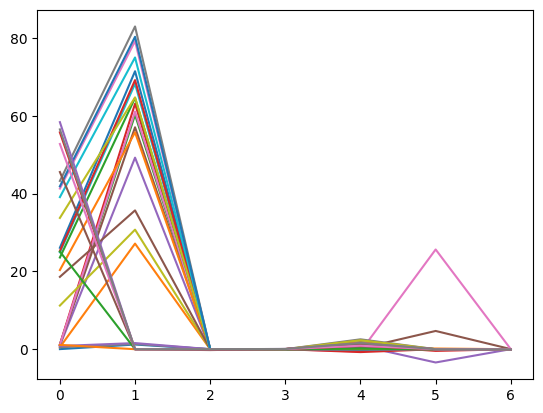

In [434]:
idx = soap.get_location(("H", "C"))
_ = soap_ase_atoms[:,idx].reshape(soap_ase_atoms.shape[0], n_max, n_max*(l_max+1))
print(_.shape)
x_ = np.arange(0, r_cut, r_cut/n_max)
_ = plt.plot(_[-1])


(2160, 7, 16)


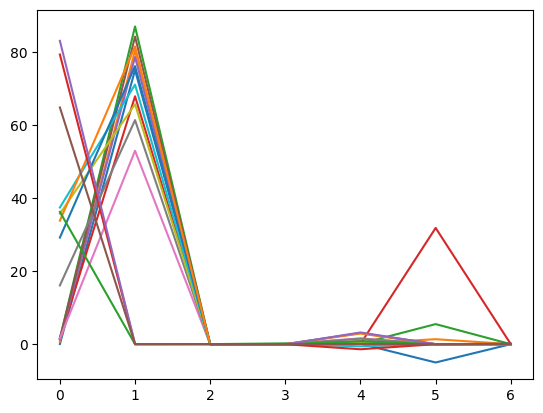

In [429]:
idx = soap.get_location(("C", "C"))
_ = soap_ase_atoms[:,idx].reshape(soap_ase_atoms.shape[0], n_max,  n_max - 2 *(l_max+1) *(l_max+1))
print(_.shape)
x_ = np.arange(0, r_cut, r_cut/n_max)
_ = plt.plot(_[-1])

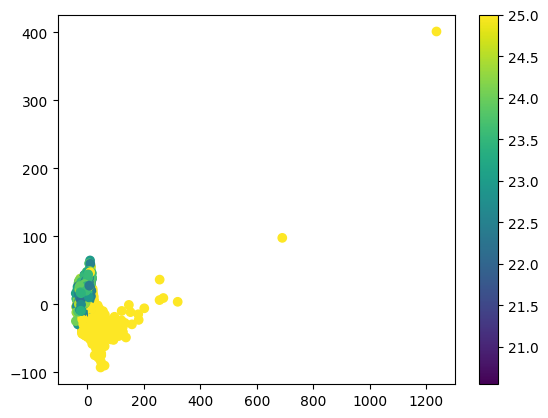

In [418]:
X = cm_desc_ase_atoms

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
pca.fit(X)
RES = pca.fit_transform(X)
s = plt.scatter(*RES.T, c=energies_df["NBOND"], vmin=energies_df["NBOND"].min(), vmax=25)
plt.colorbar(s)

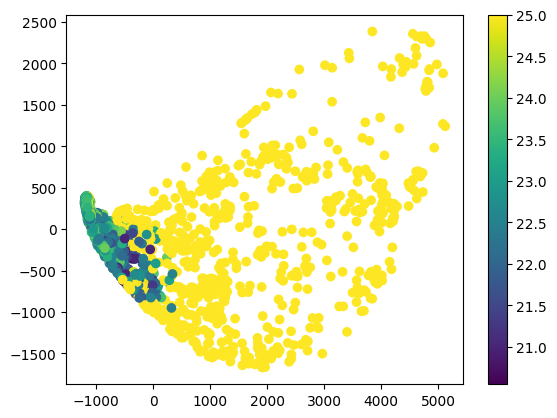

In [126]:
X = soap_ase_atoms_

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
pca = PCA(n_components=2)
pca.fit(X)
RES = pca.fit_transform(X)
energies_df["PCA1"] = RES.T[0]
energies_df["PCA2"] = RES.T[1]

s = plt.scatter(energies_df["PCA1"], energies_df["PCA2"], c=energies_df["NBOND"], vmin=energies_df["NBOND"].min(), vmax=25)
plt.colorbar(s)

In [129]:
soap_ase_atoms_

array([[ 6.77546398e-04,  1.88223734e-02,  6.10128397e-02, ...,
         1.51074785e+00,  1.52299234e-01,  7.97981770e-01],
       [ 8.69382527e-04,  2.26134951e-02,  7.25016315e-02, ...,
         1.25157850e+00,  3.43553909e-01,  7.47155383e-01],
       [ 6.29197733e-04,  1.82329891e-02,  5.84643666e-02, ...,
         1.63742857e+00,  6.83727831e-02,  8.64262415e-01],
       ...,
       [ 6.51623992e-04,  1.96449803e-02,  6.05754215e-02, ...,
         2.79098661e+00, -1.40328958e+00,  2.38158480e+00],
       [ 3.96839625e-04,  1.43749785e-02,  4.65729481e-02, ...,
         5.04723202e+00, -4.30763708e+00,  5.84811000e+00],
       [ 6.62661263e-04,  2.04314094e-02,  6.17327374e-02, ...,
         5.47753294e+00, -7.21387623e+00,  1.26626617e+01]],
      shape=(2160, 22848))

In [430]:
pycharmm.coor.set_positions(xyzs[1])
view_pycharmm_state()

In [427]:
_ = list(energies_df.index)[1]

pycharmm.coor.set_positions(xyzs[-1])
view_pycharmm_state()

In [128]:
cc_mol_zmat = cc_mol_xyz.to_zmat()
cc_mol_zmat

/home/ericb/mmml/.venv/lib/python3.13/site-packages/chemcoord/cartesian_coordinates/_cartesian_class_get_zmat.py:734: DeprecationWarning: Will be removed in the future. Please use give_zmat.
  warnings.warn(message, DeprecationWarning)


,atom,b,a,d,bond,angle,dihedral
6,Ce,origin,e_z,e_x,9.532828,72.314479,166.170312
2,Cd,6,e_z,e_x,1.402336,100.550546,131.623045
4,Cd,2,6,e_x,2.427649,89.984735,25.971657
7,He,6,2,4,1.080939,119.987245,-179.924767
8,Ce,4,2,6,1.402950,89.998419,0.049241
0,C,8,4,2,2.428703,29.981408,0.005757
10,C,8,4,2,1.401903,119.970698,-0.040352
3,H,2,0,8,1.079403,120.036008,179.984940
11,H,10,8,4,1.079456,119.929562,179.995938
1,Hg,0,8,4,1.079572,150.013315,-0.057203


In [ ]:
cc_mol_zmat

In [ ]:


eq = cc_mol_xyz.symmetrize(max_n=25, tolerance=0.3, epsilon=1e-5)



In [ ]:
eq

In [ ]:
eq["sym_mol"].get_pointgroup(tolerance=0.1)



In [ ]:
pycharmm.coor.set_positions(eq["sym_mol"])

In [ ]:
view_pycharmm_state()